# Two-site site-frequency spectra
The two-site (or two-locus) SFS summarizes pairs of linked segregating sites: its entry $(i, j)$ counts pairs of sites, within a genomic-distance window, at which one site has $i$ and the other $j$ derived alleles. Departures from the outer product of the one-dimensional spectrum reflect linkage and non-Kingman genealogies. Setting `two_sfs=True` makes the {class}`~sfsutils.parser.Parser` pair sites within `two_sfs_distance` base pairs and return a square {class}`~sfsutils.spectrum.TwoSFS`.

In [1]:
import matplotlib.pyplot as plt
from sfsutils.settings import Settings

plt.rcParams['figure.figsize'] = [4.4, 3.3]
Settings.disable_pbar = True

In [2]:
import sfsutils as su

vcf = "resources/genome/betula/biallelic.polarized.subset.10000.vcf.gz"

sfs2 = su.Parser(vcf=vcf, n=20, two_sfs=True, two_sfs_distance=1000).parse()

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file


INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Skipped 376 sites without ancestral allele information.
INFO:Parser: Included 9599 out of 10000 sites in total from the VCF file.
INFO:Parser: Counted 855831 site pairs within 1000 bp.


The matrix is symmetric and can be shown as a heatmap; the monomorphic rows and columns are omitted.

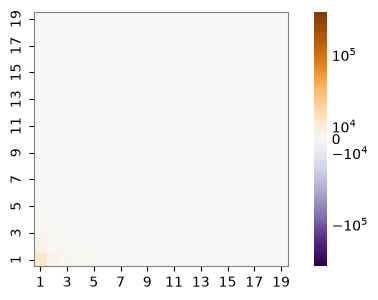

In [3]:
sfs2.plot();

Folding the spectrum (when the ancestral state is unknown) and masking the diagonals are available as for any {class}`~sfsutils.spectrum.TwoSFS`.

In [4]:
sfs2.fold().is_folded()

np.True_

## Branch-length covariance and correlation
Beyond the pair counts, {meth}`~sfsutils.spectrum.TwoSFS.cov` and {meth}`~sfsutils.spectrum.TwoSFS.corr` give the class-resolved branch-length covariance and correlation of the two linked sites, $\mathrm{Cov}(L_i, L_j)$: entry $(i, j)$ is the covariance of the branch lengths subtending $i$ and $j$ derived alleles. They are the deviation of the full joint class distribution from independence, $P(i, j) - P(i)\,P(j)$, normalized over the whole spectrum so that $P(i)$ is the site-frequency spectrum. This matches the branch-length covariance of coalescent theory (PhaseGen's `sfs2.mean - outer(sfs.mean)`) and exposes, for instance, the positive low-frequency correlations that multiple-merger genealogies produce.

Because the marginal must be the true per-site class distribution, they require the monomorphic sites: parse an all-sites input. Each is returned as a {class}`~sfsutils.spectrum.TwoSFS` over the segregating interior and plots like any other.

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file


INFO:PolyAllelicFiltration: Filtered out 15 sites.
INFO:Parser: Skipped 56 sites without ancestral allele information.
INFO:Parser: Included 9918 out of 10000 sites in total from the VCF file.
INFO:Parser: Counted 5930224 site pairs within 1000 bp.


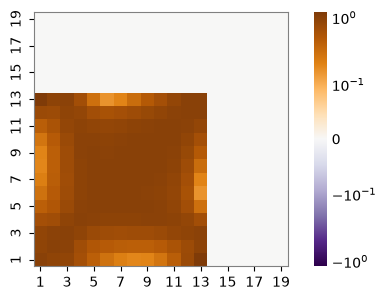

In [5]:
sfs2_all = su.Parser(vcf="resources/genome/betula/all.polarized.subset.10000.vcf.gz", n=20,
                     two_sfs=True, two_sfs_distance=1000).parse()
sfs2_all.corr().plot();

Only an all-sites input carries the monomorphic sites that anchor the marginal to the site-frequency spectrum; a polymorphic-only (SNP) spectrum leaves the branch-length covariance undefined and raises. A {class}`~sfsutils.parser.TargetSiteCounter` cannot substitute for them, so it is not supported together with the two-SFS.